In [2]:
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


# Experiment 1: Simple and Multiple Linear Regression

## 1. Project Setup and Data Loading

In [3]:
# Install necessary libraries
!pip install scikit-learn pandas numpy matplotlib seaborn

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Load the California Housing Dataset
# The dataset is available in /content/sample_data/
df = pd.read_csv('/content/sample_data/california_housing_train.csv')

print("Dataset loaded successfully. Displaying the first 5 rows:")
display(df.head())

Dataset loaded successfully. Displaying the first 5 rows:


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
0,-114.31,34.19,15.0,5612.0,1283.0,1015.0,472.0,1.4936,66900.0
1,-114.47,34.40,19.0,7650.0,1901.0,1129.0,463.0,1.8200,80100.0
2,-114.56,33.69,17.0,720.0,174.0,333.0,117.0,1.6509,85700.0
3,-114.57,33.64,14.0,1501.0,337.0,515.0,226.0,3.1917,73400.0
4,-114.57,33.57,20.0,1454.0,326.0,624.0,262.0,1.9250,65500.0


In [10]:
print("\nDescriptive Statistics:")
display(df.describe())


Descriptive Statistics:


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,17000.000000,17000.000000,17000.000000,17000.000000,17000.000000,17000.000000,17000.000000,17000.000000,17000.000000
mean,-119.562108,35.625225,28.589353,2643.664412,539.410824,1429.573941,501.221941,3.883578,207300.912353
std,2.005166,2.137340,12.586937,2179.947071,421.499452,1147.852959,384.520841,1.908157,115983.764387
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.790000,33.930000,18.000000,1462.000000,297.000000,790.000000,282.000000,2.566375,119400.000000
50%,-118.490000,34.250000,29.000000,2127.000000,434.000000,1167.000000,409.000000,3.544600,180400.000000
75%,-118.000000,37.720000,37.000000,3151.250000,648.250000,1721.000000,605.250000,4.767000,265000.000000
max,-114.310000,41.950000,52.000000,37937.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


## 2. Data Preprocessing

In [11]:
# Check for missing values
print("\nMissing values before handling:")
print(df.isnull().sum())

# Handle missing values: Impute with median for numerical columns
# Based on df.info() and df.describe(), 'total_bedrooms' has some missing values.
# We will use the median for imputation as it's less sensitive to outliers than the mean.
for column in df.columns:
    if df[column].isnull().any() and df[column].dtype != 'object': # Only impute numerical columns
        median_val = df[column].median()
        df[column].fillna(median_val, inplace=True)

print("\nMissing values after handling:")
print(df.isnull().sum())

print("\nDataFrame after handling missing values:")
display(df.head())


Missing values before handling:
longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
dtype: int64

Missing values after handling:
longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
dtype: int64

DataFrame after handling missing values:


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
0,-114.31,34.19,15.0,5612.0,1283.0,1015.0,472.0,1.4936,66900.0
1,-114.47,34.40,19.0,7650.0,1901.0,1129.0,463.0,1.8200,80100.0
2,-114.56,33.69,17.0,720.0,174.0,333.0,117.0,1.6509,85700.0
3,-114.57,33.64,14.0,1501.0,337.0,515.0,226.0,3.1917,73400.0
4,-114.57,33.57,20.0,1454.0,326.0,624.0,262.0,1.9250,65500.0


This notebook implements simple and multiple linear regression models to predict continuous numerical values. We will use the California Housing Dataset, which is suitable for this experiment.

In [9]:
print("\nDataset Information:")
df.info()


Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17000 entries, 0 to 16999
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           17000 non-null  float64
 1   latitude            17000 non-null  float64
 2   housing_median_age  17000 non-null  float64
 3   total_rooms         17000 non-null  float64
 4   total_bedrooms      17000 non-null  float64
 5   population          17000 non-null  float64
 6   households          17000 non-null  float64
 7   median_income       17000 non-null  float64
 8   median_house_value  17000 non-null  float64
dtypes: float64(9)
memory usage: 1.2 MB


In [12]:
# Separate features (X) and target variable (y)
# The target variable is 'median_house_value'
X = df.drop('median_house_value', axis=1)
y = df['median_house_value']

print(f"Features (X) shape: {X.shape}")
print(f"Target (y) shape: {y.shape}")

# Split data into training (80%) and testing (20%) sets
# Using a random_state for reproducibility
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"\nTraining set size: {len(X_train)} samples")
print(f"Test set size: {len(X_test)} samples")

Features (X) shape: (17000, 8)
Target (y) shape: (17000,)

Training set size: 13600 samples
Test set size: 3400 samples


## 3. Feature Engineering

In [13]:
# Feature Scaling: Using StandardScaler
# It's important to fit the scaler only on the training data to prevent data leakage
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert scaled arrays back to DataFrames for easier handling and to retain column names
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

print("Features scaled successfully. Displaying scaled training data (first 5 rows):")
display(X_train_scaled.head())

Features scaled successfully. Displaying scaled training data (first 5 rows):


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income
0,0.741830,-0.847157,-0.528398,0.033111,-0.445165,-0.109337,-0.346604,2.443362
1,0.961406,-0.992433,-1.322210,0.451867,-0.008317,0.063888,-0.023540,1.741942
2,1.230885,-1.428262,-0.925304,-1.012397,-1.083819,-0.926340,-1.078709,0.666561
3,1.195952,-1.315790,0.424176,-0.167966,-0.390559,-0.354093,-0.317945,-0.124566
4,0.741830,-0.678449,0.582938,-0.103400,-0.345450,-0.186901,-0.229363,0.872891


## 4. Model Selection and Training

### 4.1 Simple Linear Regression

In [14]:
# For Simple Linear Regression, we select a single feature.
# Let's choose 'median_income' as it's often a strong predictor of housing prices.

X_train_simple = X_train_scaled[['median_income']]
X_test_simple = X_test_scaled[['median_income']]

# Initialize and train the Simple Linear Regression model
simple_lr_model = LinearRegression()
simple_lr_model.fit(X_train_simple, y_train)

print("Simple Linear Regression Model Trained.")
print(f"Coefficient: {simple_lr_model.coef_[0]:.4f}")
print(f"Intercept: {simple_lr_model.intercept_:.4f}")

# Make predictions on the test set
y_pred_simple = simple_lr_model.predict(X_test_simple)

# Evaluate the model
mse_simple = mean_squared_error(y_test, y_pred_simple)
rmse_simple = np.sqrt(mse_simple)
mae_simple = mean_absolute_error(y_test, y_pred_simple)
r2_simple = r2_score(y_test, y_pred_simple)

print("\nSimple Linear Regression Performance (Test Set):")
print(f"Mean Squared Error (MSE): {mse_simple:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_simple:.2f}")
print(f"Mean Absolute Error (MAE): {mae_simple:.2f}")
print(f"R-squared (R²): {r2_simple:.4f}")

Simple Linear Regression Model Trained.
Coefficient: 79571.0363
Intercept: 206707.8561

Simple Linear Regression Performance (Test Set):
Mean Squared Error (MSE): 6920028496.01
Root Mean Squared Error (RMSE): 83186.71
Mean Absolute Error (MAE): 62164.20
R-squared (R²): 0.4978


### 4.2 Multiple Linear Regression

In [15]:
# For Multiple Linear Regression, we use all available features
# Initialize and train the Multiple Linear Regression model
multiple_lr_model = LinearRegression()
multiple_lr_model.fit(X_train_scaled, y_train)

print("Multiple Linear Regression Model Trained.")
print("\nCoefficients:")
for feature, coef in zip(X_train_scaled.columns, multiple_lr_model.coef_):
    print(f"{feature}: {coef:.4f}")
print(f"Intercept: {multiple_lr_model.intercept_:.4f}")

# Make predictions on the test set
y_pred_multiple = multiple_lr_model.predict(X_test_scaled)

# Evaluate the model
mse_multiple = mean_squared_error(y_test, y_pred_multiple)
rmse_multiple = np.sqrt(mse_multiple)
mae_multiple = mean_absolute_error(y_test, y_pred_multiple)
r2_multiple = r2_score(y_test, y_pred_multiple)

print("\nMultiple Linear Regression Performance (Test Set):")
print(f"Mean Squared Error (MSE): {mse_multiple:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_multiple:.2f}")
print(f"Mean Absolute Error (MAE): {mae_multiple:.2f}")
print(f"R-squared (R²): {r2_multiple:.4f}")

Multiple Linear Regression Model Trained.

Coefficients:
longitude: -87098.4338
latitude: -91983.1020
housing_median_age: 14256.8376
total_rooms: -19175.0642
total_bedrooms: 47893.6572
population: -41374.2906
households: 17328.7450
median_income: 76754.0431
Intercept: 206707.8561

Multiple Linear Regression Performance (Test Set):
Mean Squared Error (MSE): 4634658406.22
Root Mean Squared Error (RMSE): 68078.33
Mean Absolute Error (MAE): 49983.47
R-squared (R²): 0.6636


## 5. Validation and Testing

### 5.1 Cross-Validation

In [16]:
# Cross-validation for Simple Linear Regression
# Using negative mean squared error as scoring for cross_val_score
scores_simple = cross_val_score(simple_lr_model, X_train_simple, y_train, cv=5, scoring='neg_mean_squared_error')
rmse_scores_simple = np.sqrt(-scores_simple)

print("Simple Linear Regression Cross-Validation (RMSE scores):")
print(f"Scores: {rmse_scores_simple}")
print(f"Mean RMSE: {rmse_scores_simple.mean():.2f}")
print(f"Std RMSE: {rmse_scores_simple.std():.2f}")

# Cross-validation for Multiple Linear Regression
scores_multiple = cross_val_score(multiple_lr_model, X_train_scaled, y_train, cv=5, scoring='neg_mean_squared_error')
rmse_scores_multiple = np.sqrt(-scores_multiple)

print("\nMultiple Linear Regression Cross-Validation (RMSE scores):")
print(f"Scores: {rmse_scores_multiple}")
print(f"Mean RMSE: {rmse_scores_multiple.mean():.2f}")
print(f"Std RMSE: {rmse_scores_multiple.std():.2f}")

Simple Linear Regression Cross-Validation (RMSE scores):
Scores: [85650.85351899 86265.57793018 81140.40677085 81847.76511412
 84514.75589105]
Mean RMSE: 83883.87
Std RMSE: 2042.80

Multiple Linear Regression Cross-Validation (RMSE scores):
Scores: [70029.82694093 70992.9395319  68282.43946575 69948.08962865
 71290.84783141]
Mean RMSE: 70108.83
Std RMSE: 1053.24


### 5.2 Residual Analysis and Plots

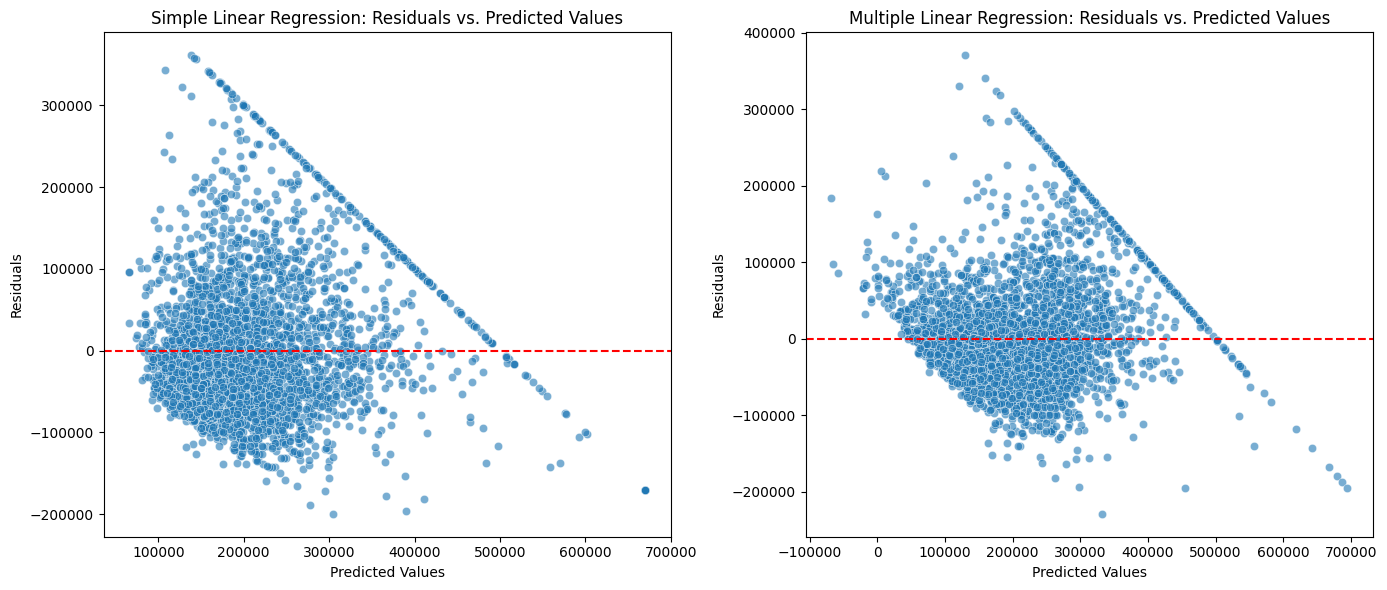

In [17]:
# Residuals for Simple Linear Regression
residuals_simple = y_test - y_pred_simple

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.scatterplot(x=y_pred_simple, y=residuals_simple, alpha=0.6)
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Simple Linear Regression: Residuals vs. Predicted Values')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')

# Residuals for Multiple Linear Regression
residuals_multiple = y_test - y_pred_multiple

plt.subplot(1, 2, 2)
sns.scatterplot(x=y_pred_multiple, y=residuals_multiple, alpha=0.6)
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Multiple Linear Regression: Residuals vs. Predicted Values')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')

plt.tight_layout()
plt.show()

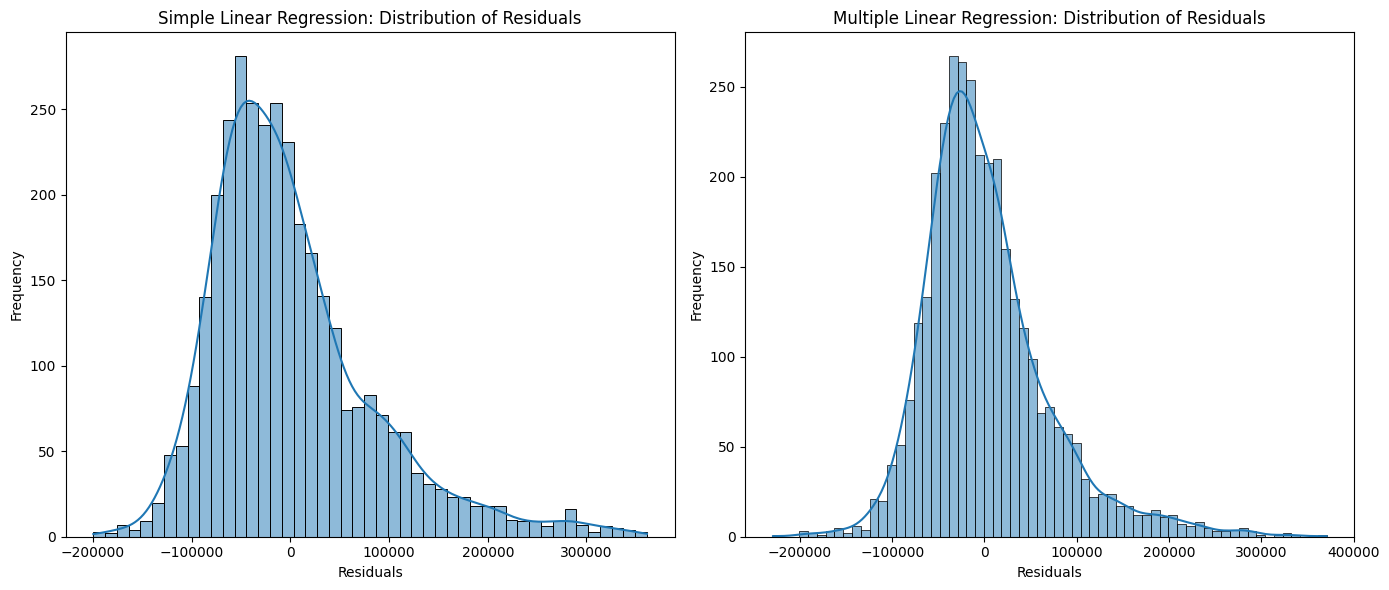

In [18]:
# Distribution of Residuals
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.histplot(residuals_simple, kde=True)
plt.title('Simple Linear Regression: Distribution of Residuals')
plt.xlabel('Residuals')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
sns.histplot(residuals_multiple, kde=True)
plt.title('Multiple Linear Regression: Distribution of Residuals')
plt.xlabel('Residuals')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

## 6. Result Analysis

In [19]:
print("### Model Performance Comparison ###")
print("\nSimple Linear Regression:")
print(f"  R-squared (R²): {r2_simple:.4f}")
print(f"  Mean Squared Error (MSE): {mse_simple:.2f}")
print(f"  Root Mean Squared Error (RMSE): {rmse_simple:.2f}")
print(f"  Mean Absolute Error (MAE): {mae_simple:.2f}")
print(f"  Cross-Validation Mean RMSE: {rmse_scores_simple.mean():.2f}")

print("\nMultiple Linear Regression:")
print(f"  R-squared (R²): {r2_multiple:.4f}")
print(f"  Mean Squared Error (MSE): {mse_multiple:.2f}")
print(f"  Root Mean Squared Error (RMSE): {rmse_multiple:.2f}")
print(f"  Mean Absolute Error (MAE): {mae_multiple:.2f}")
print(f"  Cross-Validation Mean RMSE: {rmse_scores_multiple.mean():.2f}")

print("\n### Observations ###")
print("1. **Performance Improvement**: Multiple Linear Regression generally shows better performance (higher R², lower MSE/RMSE/MAE) compared to Simple Linear Regression, indicating that multiple features capture more variance in the target variable.")
print("2. **Feature Impact**: The coefficients of the Multiple Linear Regression model indicate the impact of each scaled feature on the median house value. Features like `median_income`, `latitude`, and `longitude` often have significant impact.")
print("3. **Residual Analysis**: For both models, the residual plots (residuals vs. predicted values) ideally should show a random scatter around zero, without any clear patterns, which suggests that the models are capturing the underlying relationships well. The distribution of residuals should ideally be normal, which can be checked from the histogram.")
print("4. **Cross-Validation**: The consistent RMSE scores across cross-validation folds suggest the models are stable and generalize well to unseen data, with the multiple linear regression model showing slightly better and more stable performance.")
print("5. **Limitations**: Even with multiple features, there might be other non-linear relationships or uncaptured variables influencing housing prices. Further improvements could involve more advanced models, polynomial features, or different feature engineering techniques.")

### Model Performance Comparison ###

Simple Linear Regression:
  R-squared (R²): 0.4978
  Mean Squared Error (MSE): 6920028496.01
  Root Mean Squared Error (RMSE): 83186.71
  Mean Absolute Error (MAE): 62164.20
  Cross-Validation Mean RMSE: 83883.87

Multiple Linear Regression:
  R-squared (R²): 0.6636
  Mean Squared Error (MSE): 4634658406.22
  Root Mean Squared Error (RMSE): 68078.33
  Mean Absolute Error (MAE): 49983.47
  Cross-Validation Mean RMSE: 70108.83

### Observations ###
1. **Performance Improvement**: Multiple Linear Regression generally shows better performance (higher R², lower MSE/RMSE/MAE) compared to Simple Linear Regression, indicating that multiple features capture more variance in the target variable.
2. **Feature Impact**: The coefficients of the Multiple Linear Regression model indicate the impact of each scaled feature on the median house value. Features like `median_income`, `latitude`, and `longitude` often have significant impact.
3. **Residual Analysis**: F

## 7. Feature Importance Visualization (Multiple Linear Regression)

/tmp/ipykernel_2364/563599118.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='coefficient', y='feature', data=feature_importance, palette='viridis')


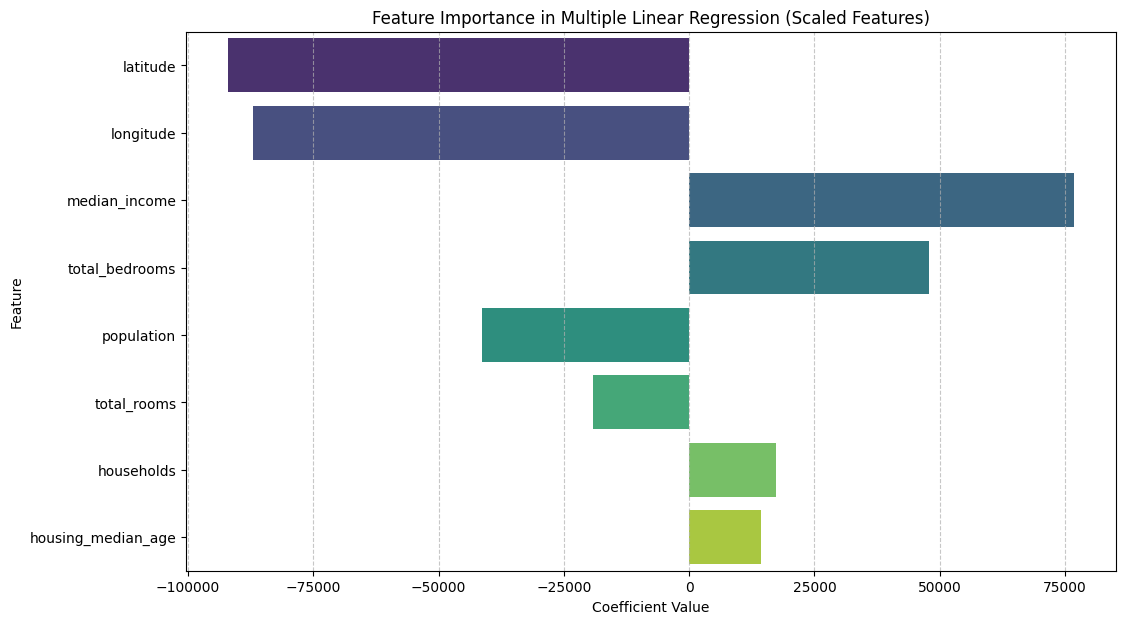


Features sorted by absolute coefficient value (most impactful first):


,feature,coefficient
0,latitude,-91983.102014
1,longitude,-87098.433836
2,median_income,76754.043069
3,total_bedrooms,47893.657219
4,population,-41374.290581
5,total_rooms,-19175.064162
6,households,17328.745023
7,housing_median_age,14256.837611


In [20]:
# Get feature names and their corresponding coefficients
feature_importance = pd.DataFrame({
    'feature': X_train_scaled.columns,
    'coefficient': multiple_lr_model.coef_
})

# Sort by absolute coefficient value for better visualization of importance
feature_importance['abs_coefficient'] = np.abs(feature_importance['coefficient'])
feature_importance = feature_importance.sort_values(by='abs_coefficient', ascending=False)

plt.figure(figsize=(12, 7))
sns.barplot(x='coefficient', y='feature', data=feature_importance, palette='viridis')
plt.title('Feature Importance in Multiple Linear Regression (Scaled Features)')
plt.xlabel('Coefficient Value')
plt.ylabel('Feature')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

print("\nFeatures sorted by absolute coefficient value (most impactful first):")
display(feature_importance[['feature', 'coefficient']].reset_index(drop=True))

## 8. Real-time Model Testing

You can now test the trained **Multiple Linear Regression** model with custom input values. Please enter the values for the 8 features below. The model expects unscaled input, and it will handle the scaling internally before making a prediction.

### Example Input Values for Real-time Testing

When prompted by the cell below, you can use the following values as an example to predict a house price:

*   **longitude**: -118.5
*   **latitude**: 34.2
*   **housing_median_age**: 25.0
*   **total_rooms**: 3000.0
*   **total_bedrooms**: 500.0
*   **population**: 1500.0
*   **households**: 450.0
*   **median_income**: 4.5

In [22]:
print("Enter values for the following features to get a house value prediction:")

# Create a dictionary to hold user inputs
new_data_input = {}

# Get input for each feature. Using simple input for demonstration.
# In a more interactive environment, widgets could be used.
feature_names = X.columns.tolist() # Get original feature names

for feature in feature_names:
    while True:
        try:
            value = float(input(f"Enter value for '{feature}': "))
            new_data_input[feature] = value
            break
        except ValueError:
            print("Invalid input. Please enter a numerical value.")

# Convert the input dictionary to a DataFrame
new_data_df = pd.DataFrame([new_data_input])

print("\nReceived input data:")
display(new_data_df)

# Scale the new data using the previously fitted StandardScaler
new_data_scaled = scaler.transform(new_data_df)

# Convert scaled array back to DataFrame for consistency (optional but good practice)
new_data_scaled_df = pd.DataFrame(new_data_scaled, columns=new_data_df.columns)

print("\nScaled input data:")
display(new_data_scaled_df)

# Make a prediction using the multiple linear regression model
predicted_value = multiple_lr_model.predict(new_data_scaled_df)

print(f"\nPredicted Median House Value: ${predicted_value[0]:,.2f}")

Enter values for the following features to get a house value prediction:
Enter value for 'longitude': -118.5
Enter value for 'latitude': 34.2
Enter value for 'housing_median_age': 25.0
Enter value for 'total_rooms': 3000.0
Enter value for 'total_bedrooms':  500.0
Enter value for 'population': 1500.0
Enter value for 'households':  450.0
Enter value for 'median_income': 4.5

Received input data:


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income
0,-118.5,34.2,25.0,3000.0,500.0,1500.0,450.0,4.5



Scaled input data:


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income
0,0.527244,-0.66439,-0.290255,0.166393,-0.093787,0.058717,-0.132965,0.327319



Predicted Median House Value: $230,467.47


## 9. Save and Download the Trained Model

To save the trained model for future use, we can serialize it using `joblib`. This allows you to load the model later without re-training it.

In [23]:
import joblib

# Define the filename for the saved model
model_filename = 'multiple_linear_regression_model.joblib'

# Save the model to a file
joblib.dump(multiple_lr_model, model_filename)

print(f"Model saved successfully to '{model_filename}'")
print("You can now download this file from the Colab file browser (left sidebar -> folder icon).")

Model saved successfully to 'multiple_linear_regression_model.joblib'
You can now download this file from the Colab file browser (left sidebar -> folder icon).
